In this module, we extract some insights on common subjects and their examination characteristics, based on past examination data. 
All data is sourced from https://www.vcaa.vic.edu.au/. We only use previous examination assessment reports in this notebook, as they contain the most interesting data. All custom functions used in this notebook are implemented in nb_helpers.py.

In [1]:
# Resolve path
from pathlib import Path
import sys

parent_dir = str(Path().resolve().parents[0])
sys.path.insert(0, parent_dir)

In [ ]:
from parsing import api
from scipy.stats import binom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nb_helpers import mcq_merged, pie_charts, get_mode_answers, fill_mcq_df

In [3]:
# Set the scope: popular VCE subjects with large exam component
subjects = [
    "specialist_mathematics",
    "mathematical_methods",
    "physics",
    "chemistry"
]

# more presentable, shortened aliases of subjects for visualisation purposes
subject_abbreviations = [
    "Spec. Math", 
    "Math. Methods",
    "Physics",
    "Chemistry"
]

years = range(2017, 2024) # Set timeframe

all_reports = api.process_material(subjects, years, type="report")

assert(all_reports)

In [4]:
all_reports["specialist_mathematics"]["2017_2"][0].head() 
# Empty correct_answer column. Do not have correct answers for PDF exams (2017-2019)

,question,correct_answer,%a,%b,%c,%d,%e,comments
0,1,NaN,1,8,75,4,12,"1 1\nx − ≤ ≤ ⇒ ∈ −∞ − ∪ ∞\n1\nx\n( , 1] [1, )"
1,2,NaN,9,30,11,12,37,The solve and graphing capabilities of\na CAS ...
2,3,NaN,4,4,9,47,35,Use of complex solve gives five\nsolutions.
3,4,NaN,14,7,11,15,53,None
4,5,NaN,75,6,5,10,4,None


There are some statistics & questions we may be able to investigate from this data. Below are but just a few of these which we will look at in this notebook:

- Do some subjects have a bias towards certain MCQ responses? Perhaps Chemistry exam writers are fascinated with making A) the correct answer.
- Which subjects have the highest frequency of "tricky" MCQ questions? (where the majority answer $\neq$ correct answer).
- Which subjects have the "hardest" short-answer questions (and what does it mean for a question to be hard)?
 

In [51]:
# Get all MCQ questions for each subject 
mcqs = mcq_merged(all_reports, years = years)

## Do some subjects have a bias towards certain MCQ Responses?

Let's first try finding the proportion of correct MCQ options over the years we have collected for each subject. We'll visualise this using pie charts, which are good for proportional data. Since we don't have the correct answer for every MCQ question, we will use the mode answer as a proxy for the correct answer wherever applicable. It works for noww, but this won't be a valid trick when we start looking for tricky MCQ questions, as questions with answer != mode is precisely what we are looking for!

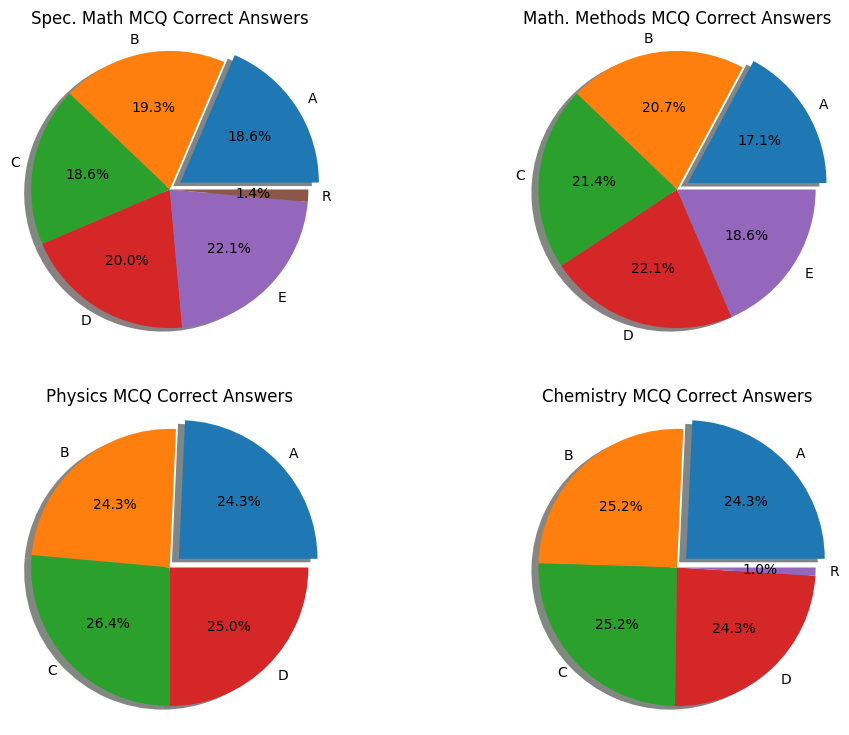

In [6]:
pie_charts(mcqs, abbrevs=subject_abbreviations, include_r=True, guess_correct=True) # Includes redacted qns + guesses correct answers

And without including redacted questions (but still guessing correct answers):

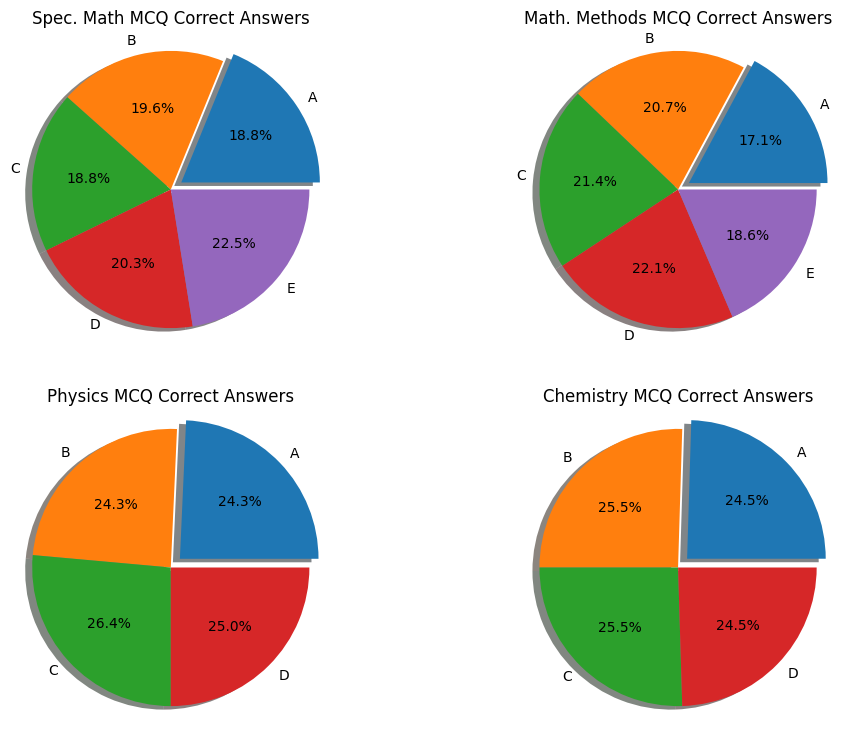

In [7]:
pie_charts(mcqs, abbrevs=subject_abbreviations, include_r=False, guess_correct=True)

The largest deviation from the uniform distribution we expect is Mathematical Methods A). We can do a quick hypothesis test here on the redacted excluded data. For those who do not know what a hypothesis test is, we are  simply checking if there is enough statistical evidence to suggest that the correct answers percentages are, in fact, not uniform, and there are other factors at play apart from the deviations with can be attributed to random chance. 

For those who do, let $p_A$ be the "true" probability of A being chosen and $\hat{p}_A$ our observed value. Then, our hypotheses are  
$$
H_0: p_A = \frac{1}{5}, \quad H_1: p_A \neq \frac{1}{5}
$$
Where, under $H_0$, we have $n\hat{p}_A ~ \sim \text{Binomial}\left(n, p_A = \frac{1}{5}\right)$. We test at the $\alpha = 0.05$ significance level.

In [8]:
proportions, df = fill_mcq_df(mcqs["mathematical_methods"], include_r = False, guess_correct = True)
n = df.shape[0]
n

140

In [9]:
alpha = 0.05 # set significance level

# We need to find the 
test_stat = n * proportions["A"]

# factor of two comes from the two-sided test using a normal approximation, valid for n=138
p_value = 2*(binom.cdf(test_stat, n, 0.2)) if test_stat / n < 0.2 else 2*(1-binom.cdf(test_stat, n, 0.2))
 
if p_value > alpha:
    print(f"The p_value of the test is {p_value:.4f}. This is greater than alpha={alpha}, "
          f"so we fail to reject H_0 at the {100*alpha}% significance level. "
          f"This amounts to saying that there is insufficient evidence to suggest "
          f"that option B is chosen an 'unfair' amount.")
elif p_value <= alpha: 
    print(f"The p_value of the test is {p_value:.4f}. This is less than f{alpha}, "
          f"so we reject H_0 at the {100*alpha}% significance level. "
          f"This amounts to saying that there is sufficient evidence to suggest "
          f"that option B is chosen an 'unfair' amount.") 

The p_value of the test is 0.4655. This is greater than alpha=0.05, so we fail to reject H_0 at the 5.0% significance level. This amounts to saying that there is insufficient evidence to suggest that option B is chosen an 'unfair' amount.


Since this was the most "extreme" deviation from the expected value that we observed, it looks like there isn't enough evidence to suggest that the probability a given MCQ response is the correct one is not any different from the probability of rolling a 1 from a 5-sided dice, just as we would expect. 

## Which subjects have the hardest MCQ section? 

In this first section, we'll define a "tricky" MCQ question to be those with a correct response that is different to the mode (most popular) response. Note this means we must restrict our analysis to the years 2020-23, where we have correct answer data available.

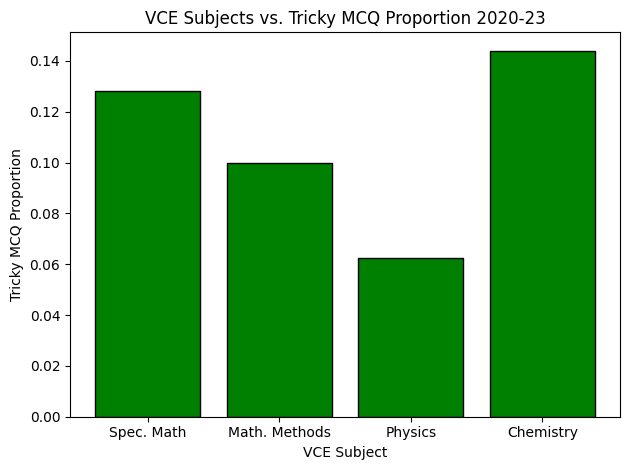

In [85]:
proportions = []

for subject in subjects:
    df = fill_mcq_df(mcqs[subject].copy(deep=True), include_r=False, guess_correct=False)[1]
    mode_answers = get_mode_answers(df)
    tricky_df = df[df["correct_answer"] != mode_answers]
    tricky_proportion = tricky_df.shape[0] / df.shape[0]
    proportions.append(tricky_proportion)

plt.bar(subject_abbreviations, proportions, color="green", edgecolor = "black")
plt.xlabel("VCE Subject")
plt.ylabel("Tricky MCQ Proportion")
plt.title("VCE Subjects vs. Tricky MCQ Proportion 2020-23")
plt.tight_layout()

So spec. math and chemistry very often get tricky MCQ questions relative to methods and physics. 

What about other indicators of difficulty? For example, the total average percentage of people who got the correct answer.

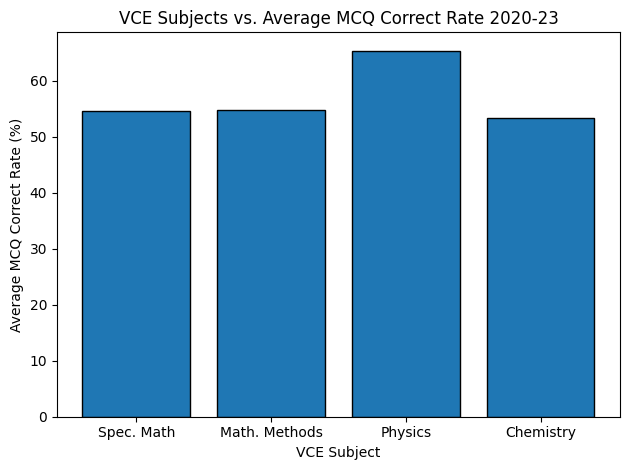

In [84]:
averages = []
for subject in subjects:
    df = fill_mcq_df(mcqs[subject].copy(deep=True), include_r=False, guess_correct=False)[1]
    correct_answer_col = df["correct_answer"].apply(lambda x: "%" + x.lower())
    df["pc_correct"] = df.apply(lambda row: row[correct_answer_col[row.name]], axis=1)
    df["pc_correct"] = df["pc_correct"].astype(float)

    averages.append(np.mean(df["pc_correct"]))

plt.bar(subject_abbreviations, averages, edgecolor="black")
plt.xlabel("VCE Subject")
plt.ylabel("Average MCQ Correct Rate (%)")
plt.title("VCE Subjects vs. Average MCQ Correct Rate 2020-23")
plt.tight_layout()

This last metric for exam difficulty I'm going to implement is a little bit more abstract. It uses something called entropy which essentially aims to quantify the uncertainty in a set of numbers which are part of the outcome set of a random variable.

To clarify, consider the table below depicting a table of MCQ option pick rates. We can see that the row with very uniformly distributed choices have high entropy (low purity). In contrast, when one option is more commonly selected than others, this purity increases and we become less "uncertain" about which answer is correct, hence a lower entropy.

| % A | % B | % C | % D | % E | Entropy 
|---|---|---|---|---|---|
| 20 | 20 | 20 | 20 | 20 | High
| 5 | 10 | 5 | 75 | 5 | Low

Intuitively, we can use this as a measure of difficulty! The less pure the distribution of options, the more split the students were in their answer, and hence the more difficult the question is. The best thing about this metric is we don't actually need to know what the correct answer is to calculate it (since the entropy is the same regardless); hence, we can use our full dataset. However, for the sake of keeping the analysis robust, we will only analyse from 2020-23. 

The following is the formula for entropy:

$$
H(X) = -\sum_{x \in \text{options}} p(x) \log p(x) 
$$

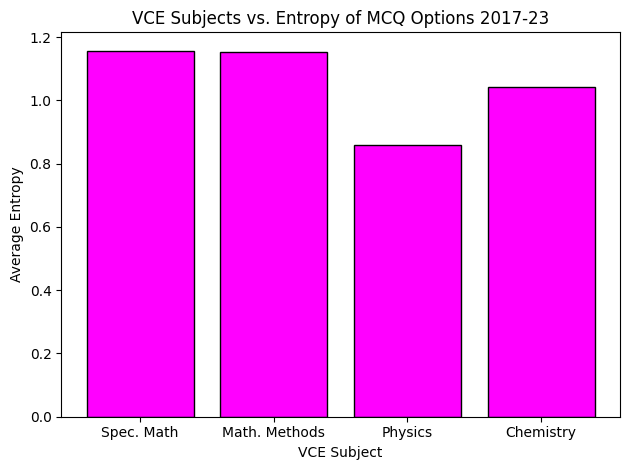

In [72]:
epsilon = 1e-6 # avoid log(0)

entropy_means = []
for subject in subjects:
    df = fill_mcq_df(mcqs[subject].copy(deep=True), include_r=False, guess_correct=True)[1]
    option_cols = df.iloc[:, 2:-1]
    option_cols = option_cols.astype(float) / 100 
    entropy_col = option_cols.apply(lambda row: -sum(row * np.log(row+epsilon)), axis=1)
    
    df["entropy"] = entropy_col
    entropy_means.append(np.mean(df["entropy"]))

plt.bar(subject_abbreviations, averages, color="magenta", edgecolor="black")
plt.xlabel("VCE Subject")
plt.ylabel("Average Entropy")
plt.title("VCE Subjects vs. Entropy of MCQ Options 2017-23")
plt.tight_layout()

I am sure there are other difficulty metrics out there but these metrics cover a good portion of what people think of when they call a question hard. Why don't we combine them into a single ```difficulty``` variable? 

In [110]:
averages

[np.float64(54.52564102564103),
 np.float64(54.8),
 np.float64(65.3625),
 np.float64(53.36440677966102)]

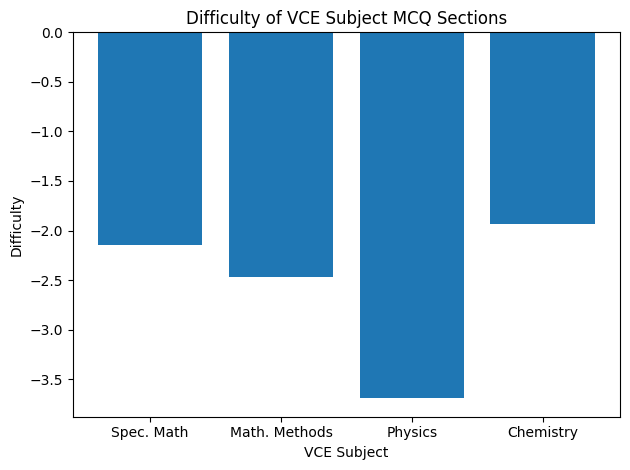

In [121]:
# currently, high average correct% => low difficulty. We want all our variables to be
# positively correlated with difficulty, so take the average incorrect% instead
ic_pc_avg = [100-avg for avg in averages]

# first standardise our values b/w subjects
proportions_s = [(proportion - np.mean(proportions)) / np.std(proportions) for proportion in proportions]
ic_pc_avg_s = [(avg - np.mean(ic_pc_avg)) / np.std(ic_pc_avg) for avg in ic_pc_avg]
entropy_means_s = [(entropy_mean - np.mean(entropy_means) / np.std(entropy_means)) for entropy_mean in entropy_means]

# we want to use equal weights: all 3 difficulties capture something unique and meaningful

# compute uniform average
w1, w2, w3 = 1/3, 1/3, 1/3 
difficultys = [w1*p + w2*a + w3*e for p, a, e in \
              zip(proportions_s, ic_pc_avg_s, entropy_means_s)]

# normalise to [0, 1]
difficultys_norm = [(difficulty - min(difficultys) )/ (max(difficultys) - min(difficultys)) \
                    for difficulty in difficultys]

plt.bar(subject_abbreviations, difficultys)
plt.xlabel("VCE Subject")
plt.ylabel("Difficulty")
plt.title("Difficulty of VCE Subject MCQ Sections")
plt.tight_layout()

The difficulty metric here has no real interpretable meaning absolutely; it only really makes sense relatively. We can just as easily plot a normalised version to emphasise this.

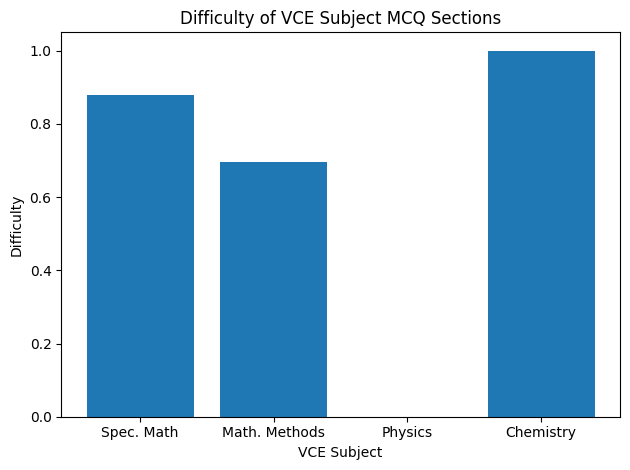

In [122]:
plt.bar(subject_abbreviations, difficultys_norm)
plt.xlabel("VCE Subject")
plt.ylabel("Difficulty")
plt.title("Difficulty of VCE Subject MCQ Sections")
plt.tight_layout()

Thus, as determined by our analysis, the most difficult VCE subject MCQ sections according to our difficulty metric is, in order:

1) Chemistry
2) Specialist Math
3) Math Methods
4) Physics

In [ ]:
# export mcq data
from paths import DATA_DIR
save_path = DATA_DIR / "report_analysis"
save_path.mkdir(exist_ok=True)
for subject in subjects:
    mcqs[subject].to_csv(save_path / f"{subject}_mcq.csv")

## Which subjects have the hardest short-answer questions?